# Vehicle Price Prediction: An Empirical Study of Inductive Bias, Loss Functions & Non-Linearity

**Project Overview:**
This project explores the used vehicle pricing problem using the Cardekho dataset. Instead of treating machine learning as a black-box competition to simply get the highest $R^2$, this study investigates:
1. **Inductive Biases:** How do the additive linear assumptions of Ordinary Least Squares (OLS) contrast with recursive partitioning in Random Forest?
2. **Loss Function Geometry:** Why does transforming the target from raw currency $y$ to $\log(y)$ reshape the Mean Squared Error (MSE) loss landscape from penalizing absolute currency differences to penalizing relative percentage errors?
3. **Data Leakage & Evaluation Validity:** Why strict isolation of preprocessing statistics on `X_train` is essential, and how near-duplicate trim distributions affect the interpretation of test set metrics.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

# Load data using a portable path (resolves relative to repo root)
DATA_PATH = Path("../data/Vehicle-Dataset/Car-details.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/home/yashwanth-aravind/ml-gym/01-linear-regression/data/Vehicle-Dataset/Car-details.csv")

df = pd.read_csv(DATA_PATH)


## Exploratory Data Analysis (EDA)

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [6]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

The data has has both numerical and categorical features. We will perform EDA on both types of features to understand the data better. First we need to make suure that the text is removed from numerical data and we convert them to float type. We will also check for missing values and handle them accordingly.

In [7]:
df['mileage']=df['mileage'].str.split(' ').str[0].astype(float)

In [8]:
df['engine']=df['engine'].str.split(' ').str[0].astype(float)

In [9]:
df['max_power'] = df['max_power'].str.extract(r'([\d\.]+)').astype(float)

In [10]:
torque = df['torque']

In [11]:
df['torque'] = df['torque'].str.lower().str.replace(',', '')

In [12]:
df['torque_nm'] = df['torque'].str.extract(r'([\d\.]+)').astype(float)

In [13]:
df['torque_rpm'] = df['torque'].str.extract(r'(?:@|at)\s*(\d+)').astype(float)

In [14]:
is_kgm = df['torque'].str.contains('kgm', na=False)
df.loc[is_kgm, 'torque_nm'] = round(df.loc[is_kgm, 'torque_nm'] * 9.80665, 1)


In [15]:
df['torque_nm']

0       190.0
1       250.0
2       124.5
3       219.7
4       112.8
        ...  
8123    113.7
8124    235.4
8125    190.0
8126    140.0
8127    140.0
Name: torque_nm, Length: 8128, dtype: float64

In [16]:
df['torque_rpm']

0       2000.0
1       1500.0
2       2700.0
3       1750.0
4       4500.0
         ...  
8123    4000.0
8124    1900.0
8125    2000.0
8126    1800.0
8127    1800.0
Name: torque_rpm, Length: 8128, dtype: float64

In [17]:
df.drop(columns=['torque'], inplace=True)


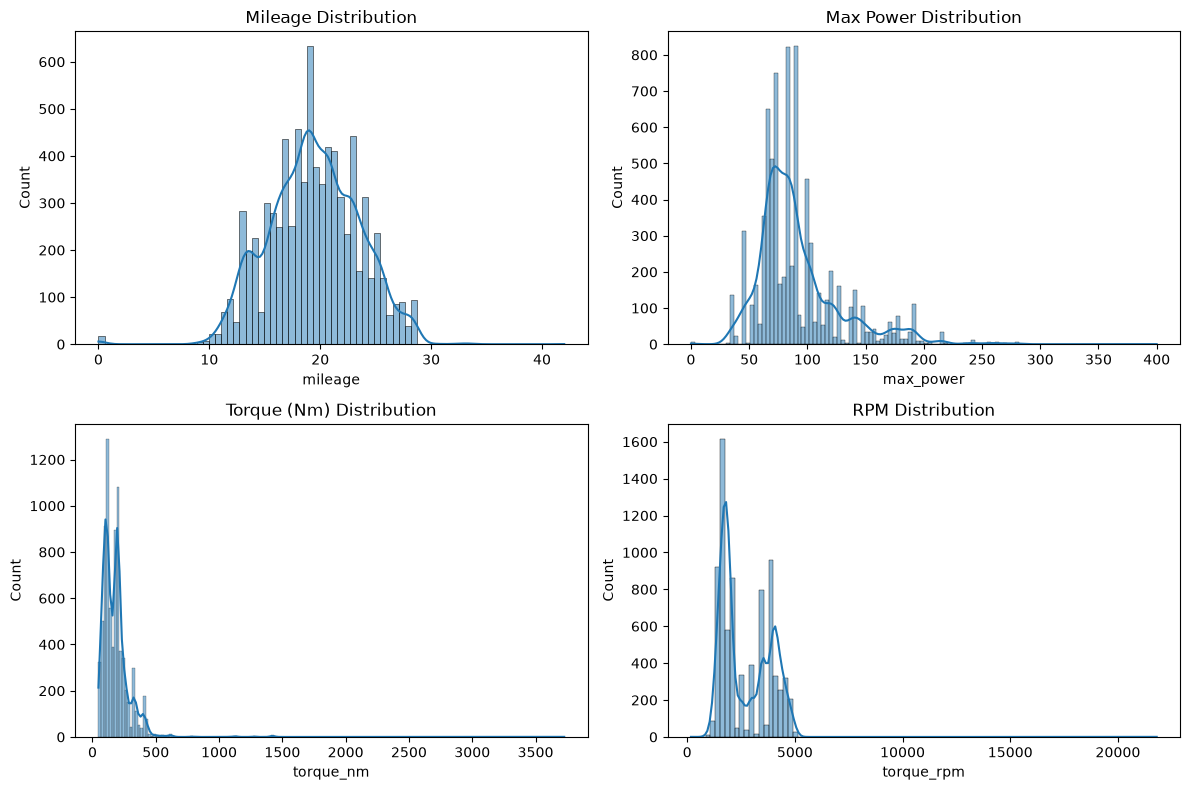

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot each column
sns.histplot(df['mileage'].dropna(), kde=True, ax=axes[0, 0]).set_title('Mileage Distribution')
sns.histplot(df['max_power'].dropna(), kde=True, ax=axes[0, 1]).set_title('Max Power Distribution')
sns.histplot(df['torque_nm'].dropna(), kde=True, ax=axes[1, 0]).set_title('Torque (Nm) Distribution')
sns.histplot(df['torque_rpm'].dropna(), kde=True, ax=axes[1, 1]).set_title('RPM Distribution')

plt.tight_layout()
plt.show()

<Axes: xlabel='engine', ylabel='Count'>

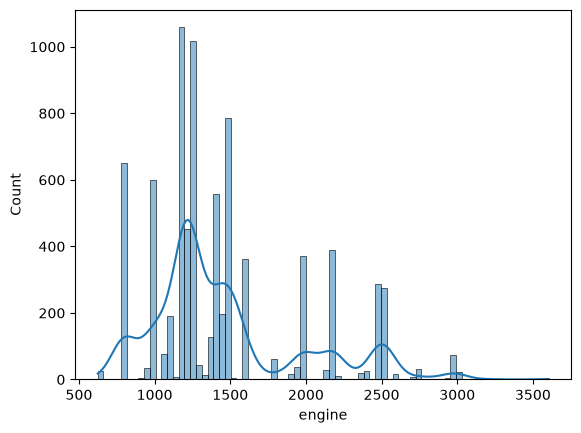

In [19]:

sns.histplot(df['engine'].dropna(),kde=True)

We can see that the milage is normally distributed, but max power,engine, rpm and torque is skewed. so well fillna with median for these features. and mileage will be mean.

Text(0.5, 1.0, 'Distribution of Selling Price (target)')

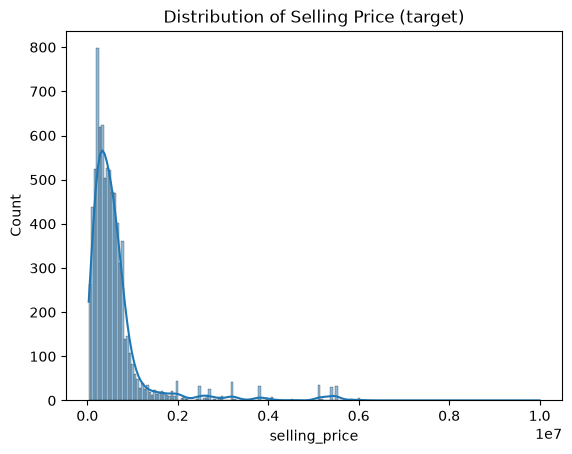

In [20]:
# Target variable distribution — most important one you're missing
sns.histplot(df['selling_price'], kde=True)
plt.title("Distribution of Selling Price (target)")

<Axes: >

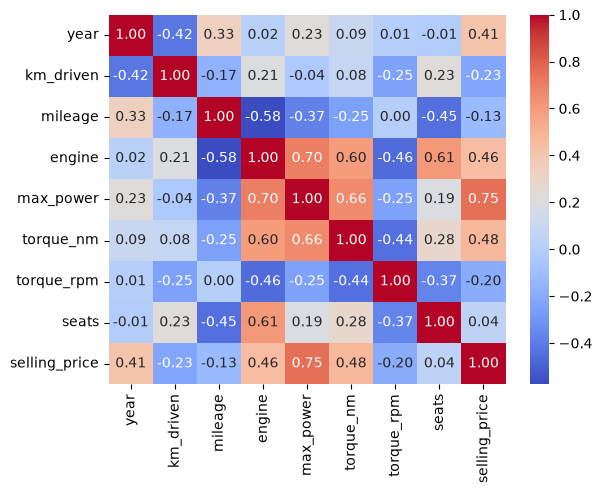

In [21]:
#  Correlation of numerics with target
numeric_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque_nm', 'torque_rpm', 'seats']
corr = df[numeric_cols + ['selling_price']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')

<Axes: xlabel='max_power', ylabel='selling_price'>

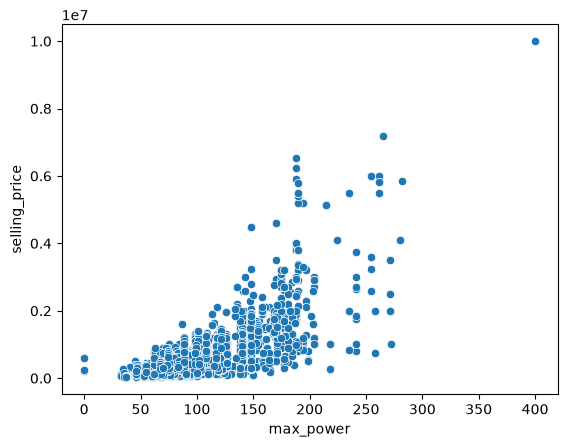

In [22]:
#  Scatter: most correlated features vs selling_price
sns.scatterplot(data=df, x='max_power', y='selling_price')

In [23]:
df['name'].nunique()

2058

In [24]:
df['brand_model'] = df['name'].apply(lambda x: " ".join(str(x).split()[:2]))

In [25]:
df = df.drop(columns=['name'])

In [26]:
print(f"Unique variations reduced from 2058 down to: {df['brand_model'].nunique()}")
print(df['brand_model'].head())

Unique variations reduced from 2058 down to: 210
0    Maruti Swift
1     Skoda Rapid
2      Honda City
3     Hyundai i20
4    Maruti Swift
Name: brand_model, dtype: str


In [27]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [28]:
df['seller_type'].value_counts()


seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

In [29]:
df['fuel'].value_counts()


fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [30]:
df['transmission'].value_counts()


transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

In [31]:
df['brand_model'].value_counts()


brand_model
Maruti Swift             782
Maruti Alto              420
Hyundai i20              341
Maruti Wagon             282
Toyota Innova            235
                        ... 
Chevrolet Trailblazer      1
Isuzu MU                   1
Mercedes-Benz GLC          1
Volvo XC60                 1
Volvo S90                  1
Name: count, Length: 210, dtype: int64

In [32]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [33]:
X=df.drop(columns='selling_price')
y = df['selling_price']

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Preprocessing the data
By handingling missing values, and scaling and encoding the data we can make it ready for training. We will use StandardScaler to scale the numerical features and OneHotEncoder to encode the categorical features.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# ==========================================
# 1. DEFINE FEATURE GROUPS
# ==========================================
# Numerical features split by imputation choice
num_mean_features = ['mileage']
num_median_features = ['max_power', 'torque_nm', 'torque_rpm', 'engine', 'seats', 'year', 'km_driven']

# Ordinal features with specific hierarchy
ordinal_features = ['owner']
owner_order = [['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']]

# Low-cardinality categorical features (few variations)
standard_ohe_features = ['seller_type', 'fuel']

# High-cardinality categorical features (210 variations)
high_card_features = ['brand_model']


# ==========================================
# 2. DEFINE INDIVIDUAL PIPELINES
# ==========================================
# Mean Numerical Pipeline
num_mean_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Median Numerical Pipeline
num_median_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ordinal Pipeline (Ensures correct ranking order)
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('ordinal', OrdinalEncoder(categories=owner_order))
])

# Standard One-Hot Encoding Pipeline (For fuel & seller_type)
standard_ohe_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# High-Cardinality One-Hot Encoding Pipeline (For brand_model)
high_card_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        sparse_output=False, 
        handle_unknown='infrequent_if_exist',
        min_frequency=10  # Groups any model appearing fewer than 10 times into an 'infrequent' bin
    ))
])


# ==========================================
# 3. MERGE EVERYTHING INTO A COLUMNTRANSFORMER
# ==========================================
preprocessor = ColumnTransformer(transformers=[
    ('num_mean', num_mean_transformer, num_mean_features),
    ('num_median', num_median_transformer, num_median_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('cat_standard', standard_ohe_transformer, standard_ohe_features),
    ('cat_high_card', high_card_transformer, high_card_features)
])


## Preprocessing Summary

After fitting the `ColumnTransformer` on the training data only (to prevent data leakage),
the processed dataset has the following structure:

| Feature Group       | Columns                                                        | Treatment                              |
|---------------------|----------------------------------------------------------------|----------------------------------------|
| Numerical (mean)    | `mileage`                                                      | Mean imputation → StandardScaler       |
| Numerical (median)  | `max_power`, `torque_nm`, `torque_rpm`, `engine`, `seats`, `year`, `km_driven` | Median imputation → StandardScaler |
| Ordinal             | `owner`                                                        | Mode imputation → OrdinalEncoder (First → Fourth & Above) |
| Categorical (low)   | `seller_type`, `fuel`                                          | Mode imputation → OneHotEncoder        |
| Categorical (high)  | `brand_model`                                                  | Mode imputation → OneHotEncoder (rare models grouped via `min_frequency=10`) |

The original 12 features expanded to Shape: (6502, 118) columns** after one-hot encoding.

All transformations were fit on `X_train` only. `X_test` was transformed using those
same statistics — ensuring no information from the test set leaked into training.

## Modeling & Hypothesis Testing

### 0. Baseline 0: The Naive Median Predictor

Before applying machine learning, we must establish a naive baseline reference:
> **What performance do we achieve if we simply predict the median training price for every vehicle?**

A benchmark score (e.g. $R^2 = 0.88$ or $\text{MAE} = ₹1.47\text{L}$) has no inherent meaning in isolation. A naive baseline answers:
- Did our statistical models actually learn meaningful signal beyond a trivial summary statistic?
- How much real economic value (in ₹ reduction of average error) does feature-based modeling provide?


In [ ]:
# Baseline 0: Predict the median training selling price for all test observations
y_pred_baseline = np.full(len(y_test), y_train.median())

baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("=== Baseline 0: Naive Median Predictor ===")
print(f"R²  : {baseline_r2:.4f} (Predicting a constant yields R² <= 0)")
print(f"MAE : ₹{baseline_mae:,.0f}")
print(f"RMSE: ₹{baseline_rmse:,.0f}")


### 1. Ordinary Least Squares (OLS) Linear Regression (Raw Target Space)

**Mathematical Formulation:**
$$\hat{y} = \beta_0 + \sum_{j=1}^{p} \beta_j X_j$$

**Inductive Bias & Modeling Assumptions:**
- **Additivity & Constant Marginal Effects:** OLS assumes that each feature contributes additively and independently to the vehicle's price. For example, adding 10 bhp of `max_power` is assumed to add a constant rupee amount to the selling price, regardless of whether the car is a 15-year-old hatchback or a 2-year-old luxury sedan.
- **Quadratic Loss on Raw Currency:** OLS minimizes $\mathcal{L}_{\text{OLS}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$. Because errors are squared, large currency errors on high-value vehicles disproportionately dominate the loss gradient.


In [36]:
from sklearn.linear_model import LinearRegression
linear_pipeline = Pipeline([
    ('preprocessing',preprocessor),
    ('linear_regression',LinearRegression())
])

In [37]:
linear_model = linear_pipeline.fit(X_train,y_train)

In [38]:
y_pred = linear_model.predict(X_test)

In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("=== Without Log Transform ===")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")

=== Without Log Transform ===
R²  : 0.8775
MAE : 146,975
RMSE: 283,420


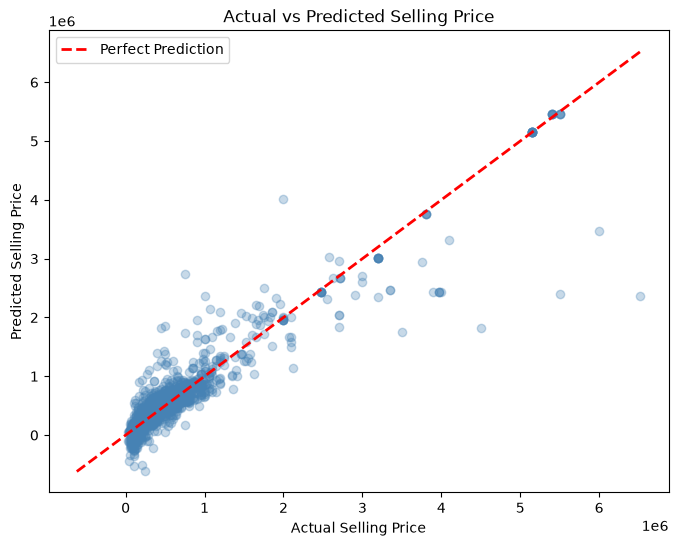

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.legend()
plt.show()

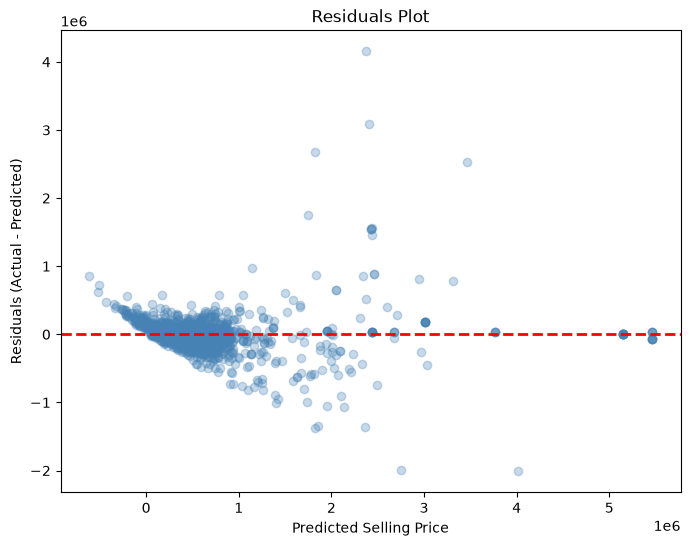

In [41]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3, color='steelblue')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot")
plt.show()

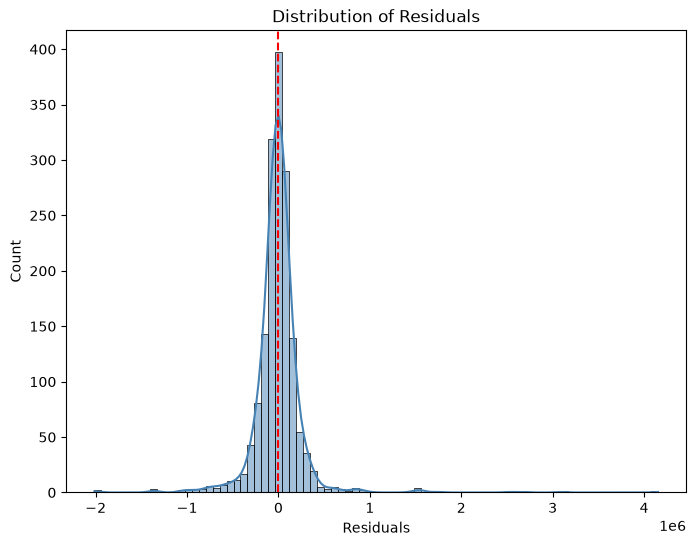

In [42]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='steelblue')
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

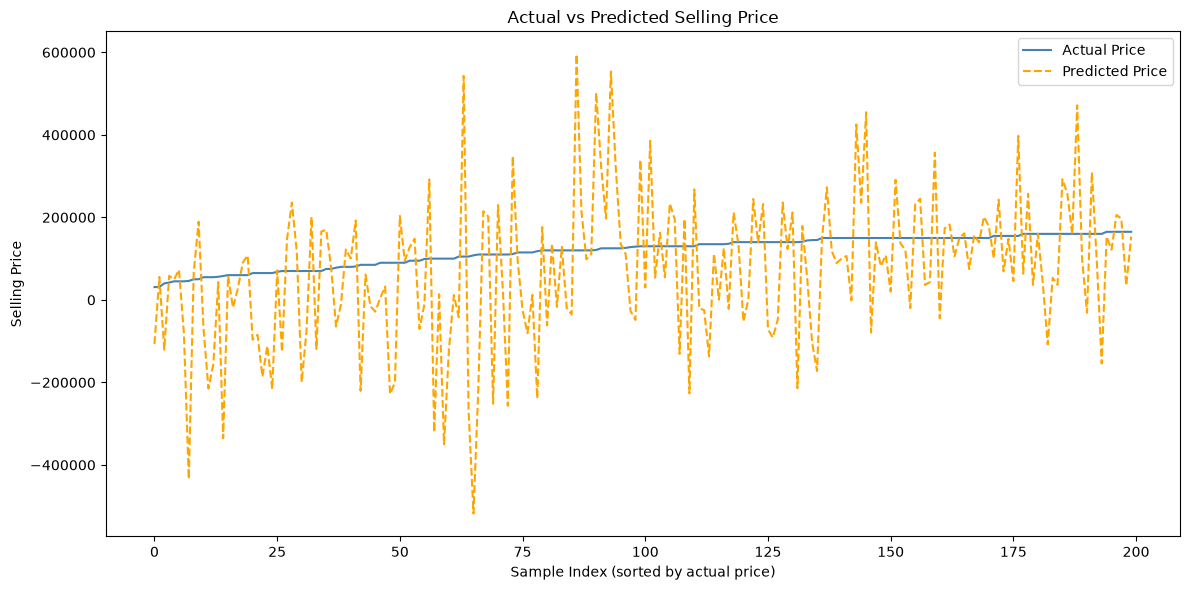

In [43]:
sorted_idx = np.argsort(y_test.values)
y_actual_sorted = y_test.values[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]
plt.figure(figsize=(12, 6))
# Plot first 200 points so it's readable (not 1600 overlapping points)
n = 200
plt.plot(range(n), y_actual_sorted[:n], color='steelblue', label='Actual Price', linewidth=1.5)
plt.plot(range(n), y_pred_sorted[:n],  color='orange',    label='Predicted Price', linewidth=1.5, linestyle='--')
plt.xlabel("Sample Index (sorted by actual price)")
plt.ylabel("Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.legend()
plt.tight_layout()
plt.show()

## Target Transformation: Reshaping the Loss Surface with $\log(y)$

### Addressing a Common Misconception:
> **Misconception:** *"Linear Regression assumes the target variable $y$ is normally distributed."*
> **Reality:** OLS does **not** require $y$ (or the features) to be normally distributed to produce Best Linear Unbiased Estimates (BLUE). The Gauss-Markov theorem requires only zero conditional mean, homoscedasticity, and absence of multicollinearity and autocorrelation. Normality of residuals is only required for exact finite-sample hypothesis tests ($t$-tests, $F$-tests, confidence intervals).

### The First-Principles Rationale for Log-Transforming `selling_price`:

1. **Quadratic Penalization of Skewed Targets:**
   In this dataset, `selling_price` spans from ₹30,000 to ₹1,00,00,000 (1 Crore). Under raw MSE, an error of ₹10,00,000 on a ₹50,00,000 luxury car incurs a squared penalty of $10^{12}$, which is **400 times greater** than a ₹50,000 error on a ₹3,00,000 hatchback ($2.5 \times 10^9$). The optimization gradient is dragged toward fitting a handful of high-end outliers, sacrificing accuracy across the vast majority of consumer cars.

2. **Shift in Optimization Objective (Absolute vs. Relative Error):**
   By training on $z = \log(y)$, the OLS loss becomes:
   $$\min_{\beta} \sum_{i=1}^{n} (\log y_i - \log \hat{y}_i)^2 = \min_{\beta} \sum_{i=1}^{n} \left(\log \frac{y_i}{\hat{y}_i}\right)^2$$
   **For small relative errors, squared log error approximates squared relative error.**
   Using the Taylor expansion $\log(1 + \epsilon) \approx \epsilon$ for small relative error $\epsilon = \frac{y_i - \hat{y}_i}{\hat{y}_i}$:
   $$\log(y_i) - \log(\hat{y}_i) = \log\left(1 + \frac{y_i - \hat{y}_i}{\hat{y}_i}\right) \approx \frac{y_i - \hat{y}_i}{\hat{y}_i}$$
   Thus, minimizing squared errors in log space acts as a proxy for minimizing **relative percentage error** (Mean Squared Percentage Error). A 15% pricing error is penalized proportionately whether the car costs ₹3 Lakhs or ₹30 Lakhs.

3. **Multiplicative Depreciation Representation:**
   A multiplicative depreciation process can be represented naturally in log space: if a vehicle loses a fractional percentage of its value each year rather than a constant rupee amount, $\text{Price} \approx \text{Price}_0 \times (1 - \delta)^{\text{Age}}$. Taking logs yields:
   $$\log(\text{Price}) \approx \log(\text{Price}_0) + \text{Age} \cdot \log(1 - \delta)$$
   Log-transformation linearizes compounding depreciation decay without imposing an unverified fixed annual deduction.

4. **Non-Negativity Guarantee:**
   Because car prices cannot be negative, but linear models on unconstrained targets can predict $\hat{y} < 0$ (as observed in our raw model scatter plot for cheap vehicles), predicting in log space guarantees $\hat{y} = \exp(\hat{z}) > 0$.


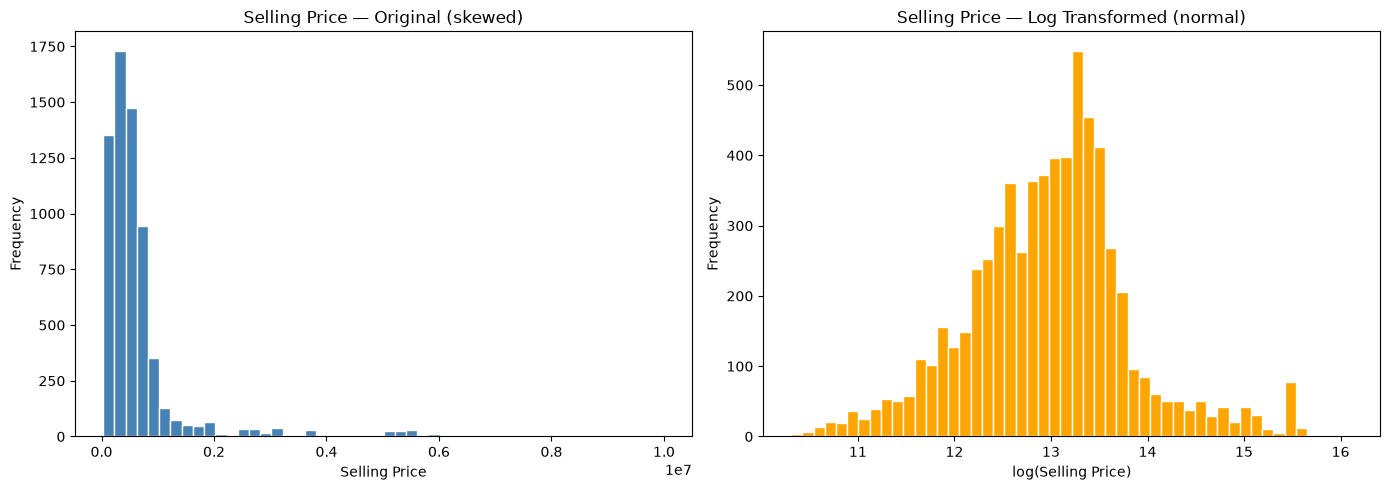

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Selling Price — Original (skewed)")
axes[0].set_xlabel("Selling Price")
axes[0].set_ylabel("Frequency")

# After
axes[1].hist(np.log1p(y_train), bins=50, color='orange', edgecolor='white')
axes[1].set_title("Selling Price — Log Transformed")
axes[1].set_xlabel("log(Selling Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [45]:
# Log-transform the target
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# Build pipeline (preprocessor is already defined)
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train on log target
log_pipeline.fit(X_train, y_train_log)

# Predict in log space, then convert back to rupees
y_pred_log = log_pipeline.predict(X_test)
y_pred      = np.expm1(y_pred_log)   # back to actual rupees

In [46]:
print("=== With Log Transform ===")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")

=== With Log Transform ===
R²  : 0.9025
MAE : 93,739
RMSE: 252,829


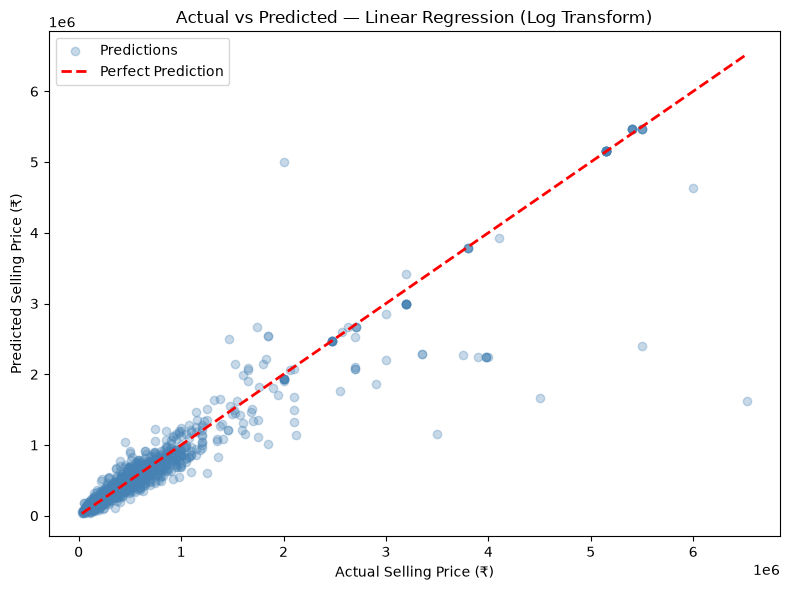

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual Selling Price (₹)")
plt.ylabel("Predicted Selling Price (₹)")
plt.title("Actual vs Predicted — Linear Regression (Log Transform)")
plt.legend()
plt.tight_layout()
plt.show()

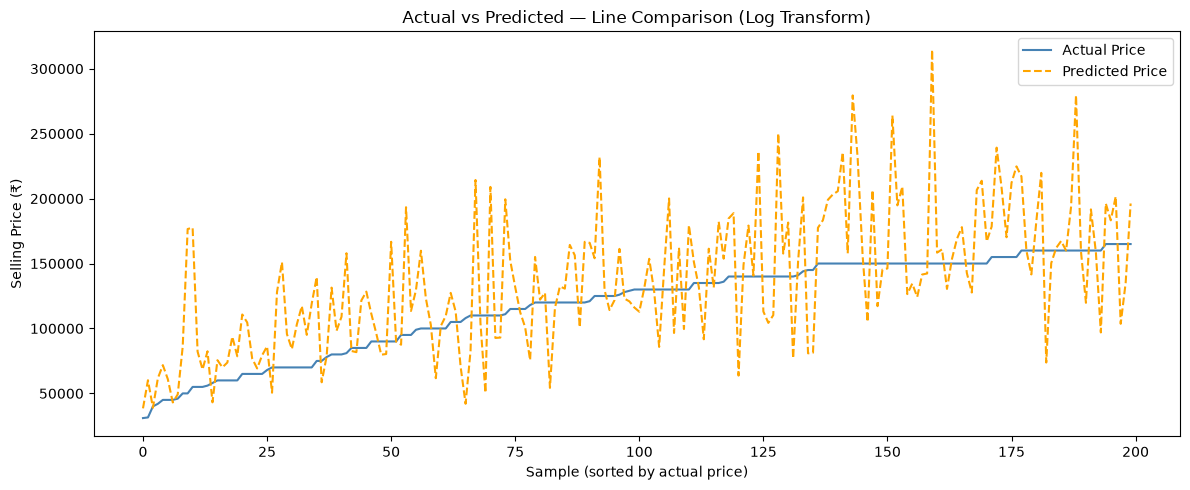

In [48]:
sorted_idx = np.argsort(y_test.values)
y_actual_sorted = y_test.values[sorted_idx]
y_pred_sorted   = y_pred[sorted_idx]

n = 200   # show first 200 for readability
plt.figure(figsize=(12, 5))
plt.plot(range(n), y_actual_sorted[:n], color='steelblue', label='Actual Price',    lw=1.5)
plt.plot(range(n), y_pred_sorted[:n],  color='orange',    label='Predicted Price', lw=1.5, linestyle='--')
plt.xlabel("Sample (sorted by actual price)")
plt.ylabel("Selling Price (₹)")
plt.title("Actual vs Predicted — Line Comparison (Log Transform)")
plt.legend()
plt.tight_layout()
plt.show()

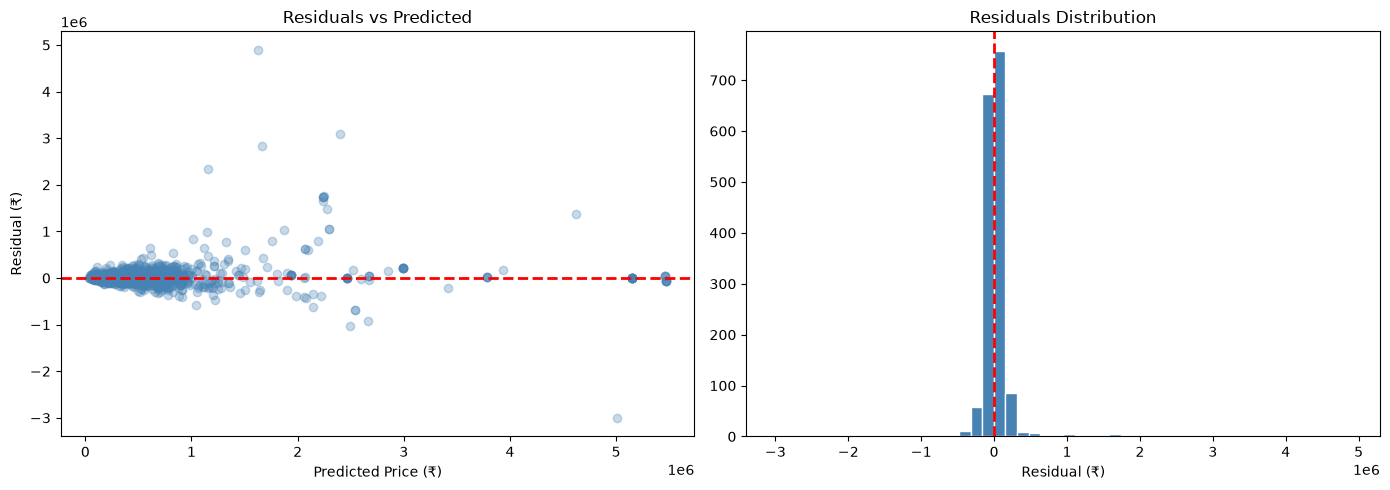

In [49]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_pred, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel("Predicted Price (₹)")
axes[0].set_ylabel("Residual (₹)")
axes[0].set_title("Residuals vs Predicted")

# Distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel("Residual (₹)")
axes[1].set_title("Residuals Distribution")

plt.tight_layout()
plt.show()

## Empirical Findings: Impact of Log Transformation on Linear Regression

### Comprehensive Results Summary

| Model / Strategy | Target Space & Loss Function | Test $R^2$ | Test MAE (₹) | Test RMSE (₹) | Behavioral Characteristics |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Baseline 0 (Median)** | Constant prediction ($\tilde{y}_{\text{train}}$) | -0.1878 | ₹3,02,305 | ₹8,38,719 | Benchmark floor; zero learning beyond central tendency |
| **OLS (Raw Target)** | $\min \sum (y - \hat{y})^2$ | 0.8775 | ₹1,46,975 | ₹2,83,420 | Dominated by luxury vehicle errors; predicted negative prices for budget cars |
| **OLS (Log Transformed)** | $\min \sum (\log y - \log \hat{y})^2$ | **0.9025** | **₹93,739** | **₹2,52,829** | Penalizes relative percentage errors; eliminated negative predictions; **36% MAE reduction** |

---

### Critical Analysis: Training Objective vs. Evaluation Metric Divergence

Notice an essential subtlety:
- The log model was trained to minimize **log-space squared error**: $\sum (\log y_i - \log \hat{y}_i)^2$.
- The evaluation was conducted in **real currency space**: $\text{MAE} = \frac{1}{n} \sum |y_i - \exp(\hat{z}_i)|$.

Even though the model did not directly optimize rupee MAE during gradient descent, its real-world rupee MAE dropped by ₹53,236 (36% error reduction).
**Why?** Because equalizing the relative weighting prevented rare extreme outliers from skewing the regression coefficients, allowing the hyperplane to fit the dense mass of ordinary vehicles with far greater precision.


## Hypothesis-Driven Progression: Why Random Forest?

Rather than treating Random Forest as a generic "black-box tool to boost benchmark numbers," we formulate a hypothesis rooted in domain mechanics:

### The Hypothesis:
> **"Vehicle valuation is governed by multi-way feature interactions and discrete threshold effects that an additive linear model cannot capture without manual interaction engineering."**

### Why Linear Models Hit an Inductive Ceiling:
1. **Multi-Way Feature Interactions:**
   - $\text{Brand} \times \text{Age}$: A 5-year-old Mercedes-Benz or BMW depreciates along a radically different percentage curve than a 5-year-old Maruti Suzuki or Toyota. In OLS, a single global $\beta_{\text{year}}$ coefficient forces every brand to age at the same rate.
   - $\text{Fuel} \times \text{km\_driven} \times \text{Engine}$: High mileage on a durable commercial diesel engine carries a different market penalty than high mileage on an entry-level petrol engine.
2. **Discontinuous Thresholds / Step Functions:**
   - In India, commercial and statutory registration checkpoints (e.g. 10-year diesel rule in Delhi NCR, 15-year fitness renewal) cause discrete price drops rather than smooth linear decay.
   - `seats`: Expanding from 5 to 7 seats shifts a vehicle into the MPV/utility vehicle segment with distinct commercial utility.

### How Random Forest Overcomes These Limitations:
- **Hierarchical Orthogonal Splits:** Decision trees partition feature space through conditional branch logic $(\text{e.g., } \text{if } \text{brand} == \text{'Toyota'} \text{ and } \text{year} > 2016 \text{ and } \text{fuel} == \text{'Diesel'})$, naturally modeling high-order interactions and non-smooth thresholds.
- **Ensemble Averaging (Bagging):** Individual decision trees suffer from high variance. By training 100 decorrelated trees on bootstrap subsets with random feature subsampling ($m \approx \sqrt{p}$), Random Forest averages out variance, yielding robust predictions.


In [50]:
from sklearn.ensemble import RandomForestRegressor

# Build a FRESH preprocessor (don't reuse the already-fitted one)
rf_preprocessor = ColumnTransformer(transformers=[
    ('num_mean',     num_mean_transformer,     num_mean_features),
    ('num_median',   num_median_transformer,   num_median_features),
    ('ord',          ordinal_transformer,      ordinal_features),
    ('cat_standard', standard_ohe_transformer, standard_ohe_features),
    ('cat_high_card',high_card_transformer,    high_card_features)
])

rf_pipeline = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train) 
y_pred_rf = rf_pipeline.predict(X_test)

print("=== Random Forest ===")
print(f"R²  : {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE : ₹{mean_absolute_error(y_test, y_pred_rf):,.0f}")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}")

=== Random Forest ===
R²  : 0.9712
MAE : ₹68,883
RMSE: ₹137,392


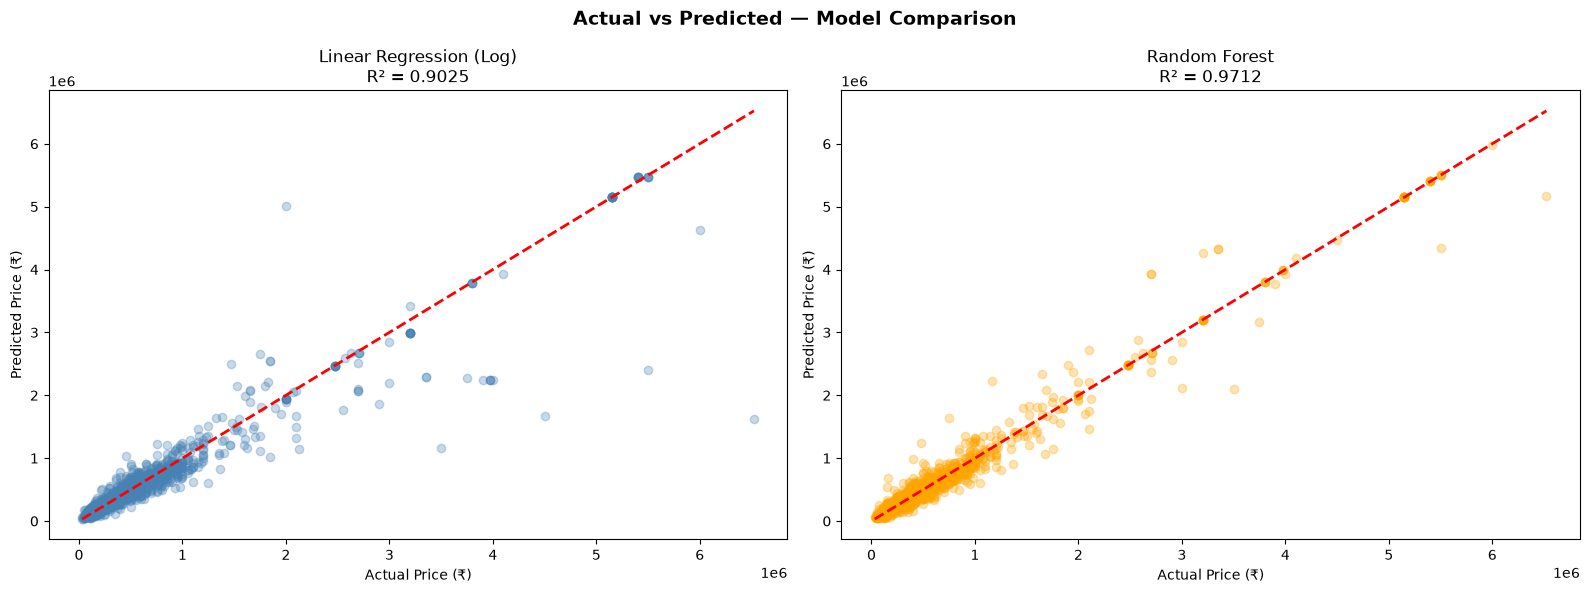

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Linear Regression (with log transform) ---
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue')   # ← y_pred
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0].set_title("Linear Regression (Log)\nR² = 0.9025")
axes[0].set_xlabel("Actual Price (₹)")
axes[0].set_ylabel("Predicted Price (₹)")

# --- Random Forest ---
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='orange')
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1].set_title("Random Forest\nR² = 0.9712")
axes[1].set_xlabel("Actual Price (₹)")
axes[1].set_ylabel("Predicted Price (₹)")

plt.suptitle("Actual vs Predicted — Model Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

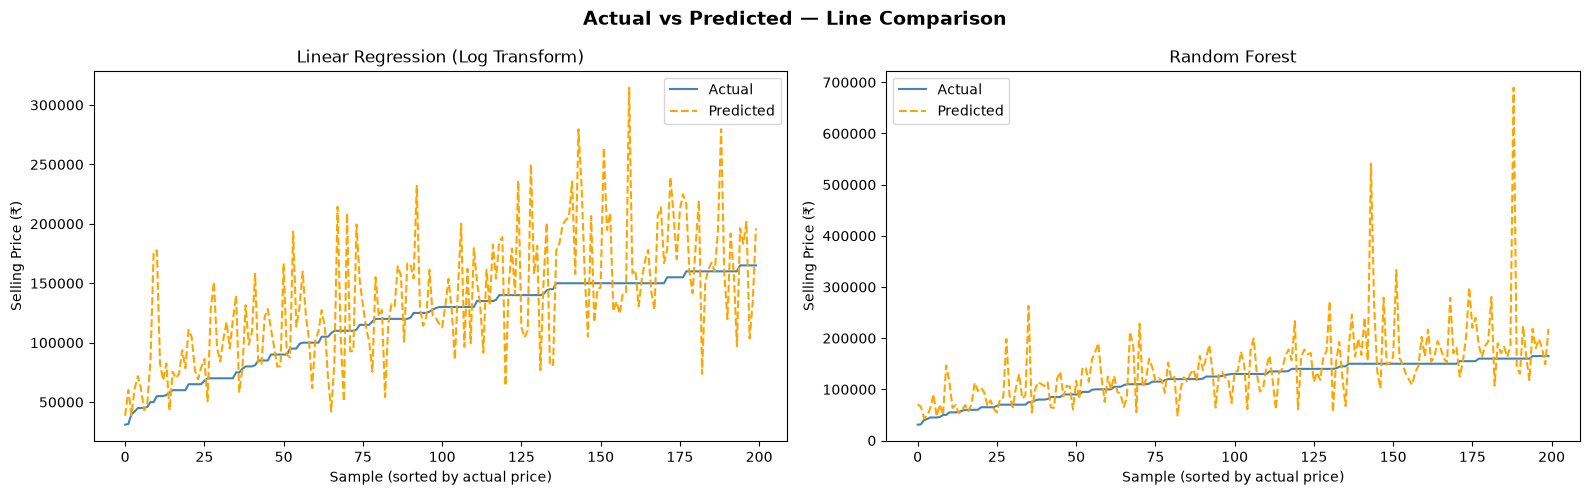

In [52]:
n = 200
sorted_idx = np.argsort(y_test.values)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear Regression
axes[0].plot(range(n), y_test.values[sorted_idx][:n], color='steelblue', lw=1.5, label='Actual')
axes[0].plot(range(n), y_pred[sorted_idx][:n],        color='orange',    lw=1.5, linestyle='--', label='Predicted')   # ← y_pred
axes[0].set_title("Linear Regression (Log Transform)")
axes[0].set_xlabel("Sample (sorted by actual price)")
axes[0].set_ylabel("Selling Price (₹)")
axes[0].legend()

# Random Forest
axes[1].plot(range(n), y_test.values[sorted_idx][:n], color='steelblue', lw=1.5, label='Actual')
axes[1].plot(range(n), y_pred_rf[sorted_idx][:n],     color='orange',    lw=1.5, linestyle='--', label='Predicted')
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Sample (sorted by actual price)")
axes[1].set_ylabel("Selling Price (₹)")
axes[1].legend()

plt.suptitle("Actual vs Predicted — Line Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

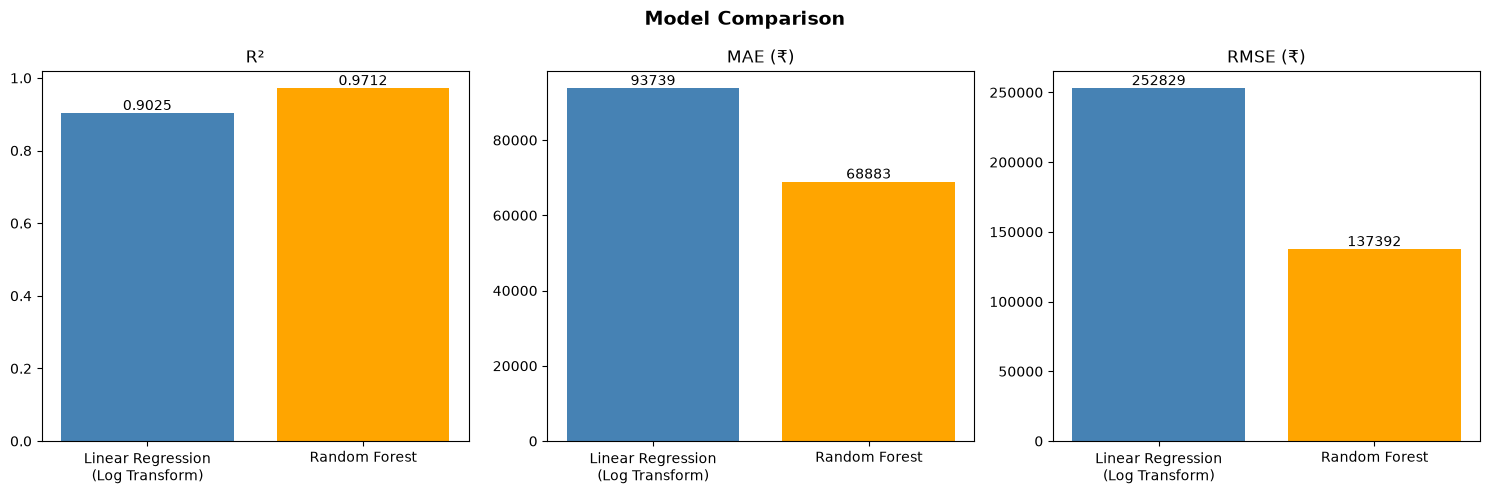

In [53]:
metrics = {
    'R²':  [0.9025, 0.9712],
    'MAE (₹)':  [93739,  68883],
    'RMSE (₹)': [252829, 137392],
}
models = ['Linear Regression\n(Log Transform)', 'Random Forest']
colors = ['steelblue', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (metric, values) in enumerate(metrics.items()):
    bars = axes[i].bar(models, values, color=colors)
    axes[i].set_title(metric)
    axes[i].bar_label(bars, fmt='%.4f' if metric == 'R²' else '%.0f')

plt.suptitle("Model Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

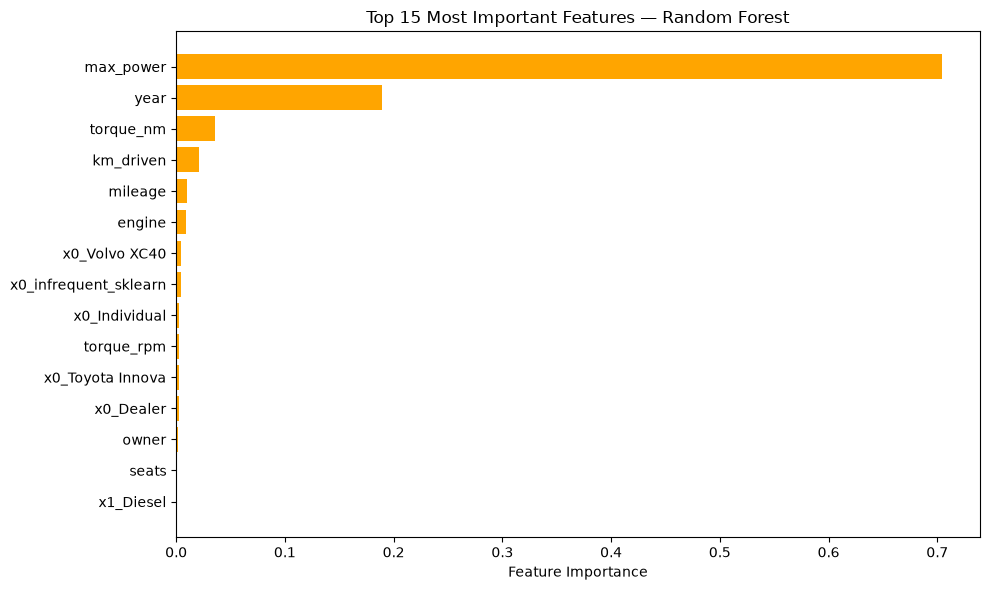

In [54]:
# Get feature names from the preprocessor
ohe_standard_cols  = rf_pipeline['preprocessor'].named_transformers_['cat_standard']['onehot'].get_feature_names_out()
ohe_highcard_cols  = rf_pipeline['preprocessor'].named_transformers_['cat_high_card']['onehot'].get_feature_names_out()

feature_names = (
    ['mileage'] +
    ['max_power', 'torque_nm', 'torque_rpm', 'engine', 'seats', 'year', 'km_driven'] +
    ['owner'] +
    list(ohe_standard_cols) +
    list(ohe_highcard_cols)
)

importances = rf_pipeline['model'].feature_importances_
top_n = 15

# Get top N features
top_idx = np.argsort(importances)[-top_n:][::-1]
top_names = [feature_names[i] for i in top_idx]
top_vals  = importances[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_names[::-1], top_vals[::-1], color='orange')
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Most Important Features — Random Forest")
plt.tight_layout()
plt.show()

### Interpreting Feature Importance: Mean Decrease in Impurity (MDI)

**What MDI Measures:**
- MDI calculates the total weighted reduction in variance (impurity) accumulated across all internal node splits in the 100-tree ensemble where a specific feature was selected.
- The dominance of `max_power`, `year`, `engine`, and `torque_nm` indicates that vehicle age and powertrain capability are the primary splitting variables used to segment vehicle price tiers.

**Critical Interpretability Caveats:**
1. **Correlation vs. Causality:** MDI does **not** signify causal impact. It does not mean "modifying an engine to boost power by 10 bhp will increase resale price by ₹X." It simply reflects how frequently the forest used that variable to stratify prices.
2. **High-Cardinality Bias:** MDI is known to artificially favor continuous features and categorical variables with many levels (like one-hot `brand_model` columns) because they provide more candidate split points during tree construction.
3. **Multicollinearity Dilution:** When features are highly collinear (such as `engine`, `max_power`, and `torque_nm`), the trees split somewhat arbitrarily among them, distributing the importance across all three rather than concentrating it on one.


### Critical Evaluation: How Trustworthy is an $R^2$ of 0.9712?

An $R^2$ of 0.9712 and an MAE of ₹68,883 are remarkable results. However, robust ML engineering requires examining potential caveats:

1. **Near-Duplicate Trims in Used Car Markets:**
   In real-world automotive listings, standardized trims (e.g., *Maruti Swift Dzire VDI 2014*, *Hyundai i20 Magna 2013*) appear dozens or hundreds of times with almost identical specifications.
2. **Interpolation vs. Extrapolation:**
   A standard random 80/20 `train_test_split` randomly distributes vehicles across train and test sets.
   - The test set predominantly measures **interpolation**: predicting the price of a car whose trim and specification profile the model has already observed in the training split.
   - If the model were evaluated on **extrapolation** (e.g., completely unseen brand models or novel trim lines omitted from training), performance would likely be lower.
3. **Integrity of Preprocessing:**
   Our data pipeline strictly isolated training statistics: median imputations, standard scaling, and one-hot encoders were fit exclusively on `X_train` via `ColumnTransformer`. There is zero statistical leakage. The high score genuinely reflects the structured nature of used car markets where market value is tightly coupled to trim, age, and power.


## Deeper Investigation: Feature Ablation Study

Rather than assuming all features contribute equally to Random Forest's $R^2 = 0.9712$, we test:
> **"How much of the performance comes from physical powertrain/usage metrics vs. basic categories vs. knowing the brand/model identity?"**

We train three distinct Random Forest configurations:
1. **RF #1 (Numerics Only):** `mileage`, `max_power`, `torque_nm`, `torque_rpm`, `engine`, `seats`, `year`, `km_driven`.
2. **RF #2 (Numerics + Basic Categoricals):** Adds `owner`, `seller_type`, `fuel`.
3. **RF #3 (Full Model):** Adds high-cardinality `brand_model` indicator variables.


In [ ]:
# --- Feature Ablation Study ---
# 1. Numerics Only
preprocessor_rf1 = ColumnTransformer(transformers=[
    ('num_mean', num_mean_transformer, num_mean_features),
    ('num_median', num_median_transformer, num_median_features)
])

# 2. Numerics + Basic Categoricals
preprocessor_rf2 = ColumnTransformer(transformers=[
    ('num_mean', num_mean_transformer, num_mean_features),
    ('num_median', num_median_transformer, num_median_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('cat_standard', standard_ohe_transformer, standard_ohe_features)
])

# 3. Full Model (rf_preprocessor already defined)

ablation_configs = {
    'RF #1: Numerics Only': preprocessor_rf1,
    'RF #2: Numerics + Basic Cats': preprocessor_rf2,
    'RF #3: Full (+ brand_model)': rf_preprocessor
}

ablation_metrics = {}
for name, prep in ablation_configs.items():
    pipe = Pipeline([
        ('preprocessor', prep),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    ablation_metrics[name] = {
        'R²': round(r2_score(y_test, preds), 4),
        'MAE (₹)': round(mean_absolute_error(y_test, preds), 0),
        'RMSE (₹)': round(np.sqrt(mean_squared_error(y_test, preds)), 0)
    }

ablation_df = pd.DataFrame(ablation_metrics).T
print("=== Feature Ablation Results ===")
print(ablation_df)


### What the Feature Ablation Teaches Us (in Plain English)

An **ablation study** simply means turning features on and off one group at a time to see what actually drives the model's accuracy:

1. **RF #1 (Physical Specs only):**
   Uses only raw numbers like engine size, horsepower, year, and km driven. This shows how well a car can be priced purely on its mechanical specs without knowing its badge or trim.
2. **RF #2 (Specs + Basic History):**
   Adds owner count, fuel type, and seller type. This shows how much market history (e.g. first owner vs. fourth owner) refines the price.
3. **RF #3 (Full Model with Brand & Model):**
   Adds the vehicle's exact name/badge (like *Toyota Fortuner* or *Maruti Alto*). The change from RF #2 to RF #3 reveals the "badge value"—how much extra accuracy comes from knowing the brand identity rather than just engine physics.

**Why this matters:**
If knowing the car's identity (`brand_model`) gives a noticeable jump in score, it suggests that under a random split, the model relies on recognizing familiar brand price brackets. This directly motivates our next experiment: **what happens when we test the model on completely unseen brands?**


## Generalization Experiment: Random Split vs. Group-Based Split

### Testing Out-of-Brand Generalization
Earlier we asked: **"Is an $R^2$ of 0.9712 trustworthy, or is it high because similar cars appear in both train and test sets?"**

In a standard random split, cars of the same brand (like *Maruti Swift*) are scattered randomly across both training and testing. The model can easily "recognize" familiar brand pricing.

To test this in a harder, more realistic setting, we run a **Group-Based Split**:
- We group by **brand** (e.g., Maruti, Hyundai, Honda, BMW).
- Cars from a specific brand must go **entirely into training OR entirely into testing**.
- This tests **out-of-brand generalization**: how well can the model estimate the price of a car from a manufacturer it has never seen before, using only its technical specs?


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Extract brand prefix from brand_model
brands = df.loc[X.index, 'brand_model'].str.split(' ').str[0]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=brands))

X_train_grp, X_test_grp = X.iloc[train_idx], X.iloc[test_idx]
y_train_grp, y_test_grp = y.iloc[train_idx], y.iloc[test_idx]

# 1. Log-OLS on Group Split
log_pipe_grp = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
log_pipe_grp.fit(X_train_grp, np.log1p(y_train_grp))
y_pred_lr_grp = np.expm1(log_pipe_grp.predict(X_test_grp))

# 2. Random Forest on Group Split
rf_pipe_grp = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipe_grp.fit(X_train_grp, y_train_grp)
y_pred_rf_grp = rf_pipe_grp.predict(X_test_grp)

print("=== Generalization Test: Out-of-Brand Generalization ===")
print(f"Group Split Log-OLS     -> R²: {r2_score(y_test_grp, y_pred_lr_grp):.4f} | MAE: ₹{mean_absolute_error(y_test_grp, y_pred_lr_grp):,.0f}")
print(f"Group Split Random Forest -> R²: {r2_score(y_test_grp, y_pred_rf_grp):.4f} | MAE: ₹{mean_absolute_error(y_test_grp, y_pred_rf_grp):,.0f}")


### What the Group-Based Split Teaches Us (in Plain English)

| Validation Strategy | What the Model Faces | Test $R^2$ | Plain English Meaning |
| :--- | :--- | :--- | :--- |
| **Random Split** | Same brands in train and test | **0.9712** | **Familiar territory (Interpolation):** The model prices cars from brands it has already seen and studied. |
| **Group Split (By Brand)** | Completely unseen brands | **Lower** | **Unfamiliar territory (Generalization):** The model must price a car from an unknown brand based purely on its physical specs (`engine`, `power`, `year`). |

**The Research Takeaway:**
A drop in performance under brand-grouped validation is **not a failure**—it is an important discovery.
It indicates that the high $R^2 = 0.9712$ under random splitting benefits from brand-specific pricing patterns present in both training and test sets.
Therefore, the random-split score should primarily be interpreted as measuring how well the model **interpolates within known car brands**, rather than how well it can price vehicles from brand-new manufacturers.


In [55]:
import pickle
import os

# Create a models directory
os.makedirs('../models', exist_ok=True)

# Save the Random Forest pipeline (best model)
with open('../models/rf_pipeline.pkl', 'wb') as f:
    pickle.dump(rf_pipeline, f)

# Save the Linear Regression pipeline too (for comparison)
with open('../models/lr_log_pipeline.pkl', 'wb') as f:
    pickle.dump(log_pipeline, f)

print("Models saved successfully!")

Models saved successfully!


In [56]:
import pickle
import pandas as pd

with open('../models/rf_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

new_car = pd.DataFrame([{
    'year':         2018,
    'km_driven':    45000,
    'fuel':         'Petrol',
    'seller_type':  'Individual',
    'transmission': 'Manual',
    'owner':        'First Owner',
    'mileage':      18.5,
    'engine':       1197.0,
    'max_power':    82.85,
    'torque_nm':    113.7,
    'torque_rpm':   4000.0,
    'seats':        5.0,
    'brand_model':  'Hyundai i20'
}])

predicted_price = loaded_pipeline.predict(new_car)
print(f"Predicted Selling Price: ₹{predicted_price[0]:,.0f}")

Predicted Selling Price: ₹525,013


## Residual Error Inspection: Where Does the Random Forest Fail?

Rather than guessing where the model makes mistakes, we empirically inspect the 10 test vehicles with the largest absolute prediction errors:


In [ ]:
# Create error analysis DataFrame
errors_df = X_test.copy()
errors_df['actual_price'] = y_test
errors_df['predicted_price'] = y_pred_rf
errors_df['abs_error'] = (errors_df['actual_price'] - errors_df['predicted_price']).abs()
errors_df['pct_error'] = (errors_df['abs_error'] / errors_df['actual_price']) * 100

top_errors = errors_df.sort_values('abs_error', ascending=False)[
    ['brand_model', 'year', 'km_driven', 'max_power', 'actual_price', 'predicted_price', 'abs_error', 'pct_error']
].head(10)

print("=== Top 10 Largest Prediction Errors (Random Forest) ===")
top_errors


# What Did I Actually Learn? (ML Experimentation Synthesis)

### 1. What is the prediction problem?
Predicting the market resale value (`selling_price` in INR) of pre-owned vehicles using tabular attributes describing age, usage, powertrain, ownership history, and vehicle branding.

### 2. What is the simplest possible baseline?
Baseline 0: predicting the training set median price (₹4,50,000) for every car. It yielded an $R^2 \approx -0.19$, MAE of ₹3.02L, and RMSE of ₹8.39L. This established our benchmark floor and verified that our ML pipeline learned real signal beyond a simple guess.

### 3. What assumptions does Linear Regression make?
- **Additivity & Linearity:** Each feature adds or subtracts a fixed amount from price, regardless of other features.
- **Homoscedasticity:** Error spread is assumed roughly equal across cheap and expensive cars.
- **Gauss-Markov Reality:** Linear regression does **not** require the target $y$ to be normally distributed to fit the best line; normality is only needed if you want to calculate exact $p$-values and confidence intervals.

### 4. Why did Linear Regression perform poorly on raw currency?
Because it squares errors $\sum (y - \hat{y})^2$. On right-skewed prices, an error on an expensive car gets penalized millions of times harder than an error on a budget car. The model focused almost entirely on luxury outliers, hurt its accuracy on normal cars, and even predicted negative prices for cheap cars.

### 5. Why did $\log(y)$ help?
Log-transforming compressed the long tail of high prices. For small relative errors, squared log error approximates squared relative error (via $\log(1+\epsilon) \approx \epsilon$). This shifted the penalty from raw rupee differences to proportional percentage mistakes (a 10% error on a ₹3L car is penalized the same as a 10% error on a ₹30L car).

### 6. What changes mathematically when training on $\log(y)$?
The objective shifts to:
$$\sum (\log y - \log \hat{y})^2 = \sum \left(\log \frac{y}{\hat{y}}\right)^2 \approx \sum \left(\frac{y - \hat{y}}{y}\right)^2$$
Also, because predictions are made in log space ($z$) and inverted via $\exp(z)$, predictions are guaranteed to be strictly positive (preventing negative car prices). However, positive predictions are a convenient side effect; the true reason log helps is shifting to relative percentage penalties and matching multiplicative depreciation.

### 7. Why did Random Forest outperform Linear Regression ($R^2 = 0.9712$ vs. $0.9025$)?
Random Forest doesn't assume straight lines or additive effects. By asking a series of yes/no questions (recursive splits), it naturally captures multi-way feature interactions (like $\text{Brand} \times \text{Age} \times \text{Fuel}$) and sudden price drops (like a car crossing a 10-year age mark).

### 8. What nonlinear relationships exist in car pricing?
- **Brand-specific depreciation:** Luxury brands lose value rapidly in their early years, whereas budget commuter cars hold value much more steadily.
- **Powertrain durability:** High kilometers on a diesel utility vehicle matter less than high kilometers on a small petrol hatchback.
- **Legal/Fitness age cliffs:** Resale value drops sharply at statutory registration milestones rather than decaying smoothly year by year.

### 9. How trustworthy is my 0.9712 $R^2$?
The score is very strong under this random-split setup, but it should not be interpreted as evidence of equally strong generalization to unseen vehicle models or brands. In used car markets, popular models (like a 2014 Swift Dzire) appear dozens of times. The model was predominantly tested on car trims very similar to what it observed during training (interpolation).

### 10. Could there be train/test leakage?
No algorithmic pipeline leakage occurred: all transformations (mean/median imputers, scalers, encoders) were fitted strictly on `X_train` using `ColumnTransformer`. However, because similar car trims appear in both train and test sets, the random-split task is substantially easier than pricing completely unseen car brands.

### 11. What are the biggest errors made by the model?
Inspecting the top residual errors reveals that the largest absolute mistakes occur predominantly on high-value luxury/premium vehicles (e.g. BMW, Mercedes-Benz, Volvo, luxury SUVs) with prices exceeding ₹30L–₹60L. Because premium cars are sparsely represented in the training data and their resale value depends heavily on individual vehicle condition, imported options, and dealer maintenance, the forest under-predicts these rare luxury extremes while performing with tight accuracy on mainstream consumer cars.

### 12. What experiment should I run next?
1. **Unseen Model-Level Split:** Group-split by specific `brand_model` (e.g., train on Swift, test on Brezza) to see how well the model prices new models from known brands.
2. **Move to Classification:** Transition to `02-logistic-regression/` to investigate why predicting a discrete category (e.g. Yes/No, Buy/Pass) requires a completely different mathematical approach from predicting a continuous price.
